# 5.0 Model training - LightGBM - Optuna search


## Imports


In [1]:
import numpy as np
import pandas as pd
import joblib
import json
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_log_error

from recruit_restaurant_visitor_forecasting.config import (
    AIR_RESTAURANT_ID_COL,
    MODELS_DIR,
    VISIT_DATE_COL,
    DAY_OF_WEEK_COL,
    VISITORS_NBR_COL,
    CITY_COL,
)
from recruit_restaurant_visitor_forecasting.dataset import read_csv, DataDir, save_csv
from recruit_restaurant_visitor_forecasting.features import GOLDEN_WEEK_FLG
from recruit_restaurant_visitor_forecasting.modeling.train import (
    build_feature_drop_list,
    load_data,
    prepare_features,
    shap_fs,
    lgbm_optuna_search,
    train_test_split_by_date,
)
from recruit_restaurant_visitor_forecasting.plots import plot_daily_pred, plot_feature_importances
from recruit_restaurant_visitor_forecasting.utils import merge_daily_pred, convert_to_serializable, get_format
from recruit_restaurant_visitor_forecasting.modeling.predict import recursive_predict

2026-01-13 14:49:07.233 | INFO     | recruit_restaurant_visitor_forecasting.config:<module>:12 - PROJ_ROOT path is: D:\mentoring_program


In [23]:
CV_SPLITS = 5
TEST_SIZE = 0.2
FIRST_ITER_TRIALS = 50
SECOND_ITER_TRIALS = 250
USELESS_FEATURES = [
    *[
        VISITORS_NBR_COL + suffix
        for suffix in ["_mean_7", "_mean_14", "_median_7", "_median_28"]
    ],
    GOLDEN_WEEK_FLG,
]
DROP_COLUMNS = [
    AIR_RESTAURANT_ID_COL,
    VISIT_DATE_COL,
    VISITORS_NBR_COL,
    DAY_OF_WEEK_COL,
    CITY_COL,
    *USELESS_FEATURES,
]

FS_TOP_K = 35
FS_VALID_SIZE = 0.2

MODEL_NAME = "lightgbm_shap_35_optuna"
MODEL_PATH = MODELS_DIR / f"{MODEL_NAME}_model.pkl"

## Load and prepare

In [4]:
features, labels = load_data()
features = prepare_features(features)
labels = labels.loc[features.index].reset_index(drop=True)
features = features.reset_index(drop=True)

In [5]:
X = features
y = labels

X_train, X_test, y_train, y_test = train_test_split_by_date(
    X, y, date_col=VISIT_DATE_COL, test_size=TEST_SIZE
)

train_dates = X_train[VISIT_DATE_COL]
test_dates = X_test[VISIT_DATE_COL]

print(f"Train set dates: {train_dates.min()} to {train_dates.max()}")
print(f"Test set dates: {test_dates.min()} to {test_dates.max()}")

Train set dates: 2016-02-01 00:00:00 to 2017-01-22 00:00:00
Test set dates: 2017-01-23 00:00:00 to 2017-04-22 00:00:00


## Training

In [21]:
def print_best_params(optuna_study):
    print("Best parameters:", optuna_study.best_params)
    print(f"Best score: {optuna_study.best_value:.5f}")

### Iteration 1

In [ ]:
study, model = lgbm_optuna_search(
    X_train,
    y_train,
    n_jobs=6,
    drop_features=DROP_COLUMNS,
    n_trials=FIRST_ITER_TRIALS,
)
print_best_params(study)

### SHAP feature selection

In [10]:
selected_features, feature_stats = shap_fs(
    X_train,
    y_train,
    model.named_steps["model"],
    drop_features=DROP_COLUMNS,
    test_size=FS_VALID_SIZE,
    top_k=FS_TOP_K,
)

In [11]:
FEATURES_TO_DROP = build_feature_drop_list(
    X.columns.tolist(),
    selected_features,
)
FEATURES_TO_KEEP = [c for c in X.columns if c not in FEATURES_TO_DROP]

print("Selected features: ", sorted(selected_features))

Selected features:  ['air_city_te', 'days_from_holiday', 'holiday_flg', 'nbr_res_visitors_diff', 'nbr_res_visitors_diff_mean_14', 'nbr_res_visitors_diff_mean_28', 'nbr_res_visitors_diff_mean_7', 'open_usually', 'opened_recently', 'res_visitors_diff', 'res_visitors_diff_mean_14', 'res_visitors_diff_mean_28', 'res_visitors_diff_mean_7', 'total_reserves', 'total_reserves_nbrs', 'visitors_dow_mean', 'visitors_dow_mean_nbrs', 'visitors_lag_1', 'visitors_lag_28', 'visitors_lag_7', 'visitors_last_month', 'visitors_mean_14', 'visitors_mean_28', 'visitors_mean_7', 'visitors_median_14', 'visitors_median_28', 'visitors_median_7', 'visitors_nbrs_lag_1', 'visitors_nbrs_lag_28', 'visitors_nbrs_median_14', 'visitors_nbrs_std_14', 'visitors_nbrs_std_28', 'visitors_std_14', 'visitors_std_28', 'visitors_std_7']


### Iteration 2

In [22]:
study, model_shap = lgbm_optuna_search(
    X_train,
    y_train,
    n_jobs=6,
    drop_features=FEATURES_TO_DROP,
    n_trials=SECOND_ITER_TRIALS,
)
print_best_params(study)

Best parameters: {'num_leaves': 30, 'max_depth': 5, 'learning_rate': 0.19301633976205942, 'n_estimators': 187, 'subsample': 0.5808959178599958, 'colsample_bytree': 0.9520853276183782, 'min_child_samples': 18, 'reg_alpha': 0.0007612760774295871, 'reg_lambda': 2.4975948670041967e-07}
Best score: 0.68920


### Scores

In [31]:
y_train_pred = model_shap.predict(X_train)
y_train_pred = np.maximum(y_train_pred, 0)

train_rmsle = np.sqrt(mean_squared_log_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Train set metrics:")
print(f"RMSLE: {train_rmsle:.4f}")
print(f"MAE:  {train_mae:.4f}")
print(f"R2:   {train_r2:.4f}")

Train set metrics:
RMSLE: 0.8343
MAE:  6.5669
R2:   0.6476


In [32]:
y_test_pred, temp_features = recursive_predict(
    model_shap,
    X_test,
    X_train,
    y_train,
    drop_cols=FEATURES_TO_DROP,
)

Predicting recursively:   0%|          | 0/90 [00:00<?, ?it/s]D:\mentoring_program\recruit_restaurant_visitor_forecasting\modeling\predict.py:148: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.77875914e+01 1.22577181e+01 8.09767597e+00 5.42475600e+00
 4.56822108e+00 1.96585236e+01 1.18384021e+01 4.09071679e+01
 3.12743234e+01 7.44350165e+00 2.94688582e+01 3.84015431e+00
 1.89029782e+01 2.99475365e+01 1.39032703e+01 9.04557982e+00
 4.43481927e-01 6.70956050e+00 2.68186411e+00 2.82532449e+01
 2.11886015e+01 3.99418814e+01 5.74788515e+00 1.10759796e+01
 9.36676203e+00 1.60252033e+01 4.14034175e+00 9.97857719e+00
 8.16321949e+00 2.43421345e+01 0.00000000e+00 4.27835165e+01
 2.49105478e+01 5.81795514e+00 3.10655826e-02 2.68900648e+01
 8.88636647e+00 3.36999385e+00 1.09234044e+01 9.15285754e+00
 1.33334761e+00 7.63191973e+00 1.51270733e+01 5.32731057e+00
 2.87963191e-01 1.80414125e+01 8.93759388e+00 3.89187

In [33]:
test_rmsle = np.sqrt(mean_squared_log_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"\nTest set metrics:")
print(f"RMSLE: {test_rmsle:.4f}")
print(f"MAE:  {test_mae:.4f}")
print(f"R2:   {test_r2:.4f}")


Test set metrics:
RMSLE: 0.8345
MAE:  7.0850
R2:   0.5593


## Graphs

### Feature importances

<Figure size 1200x1000 with 0 Axes>

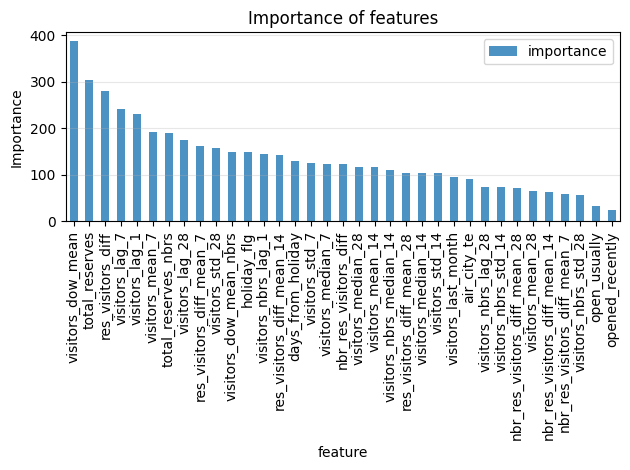

In [34]:
plot_feature_importances(model_shap, FEATURES_TO_KEEP)

## SHAP explanation

In [12]:
X_test_clean = model_shap.named_steps["feature_dropper"].transform(X_test)
lgbm = model_shap.named_steps["model"]

explainer = shap.TreeExplainer(lgbm)
shap_values = explainer(X_test_clean)

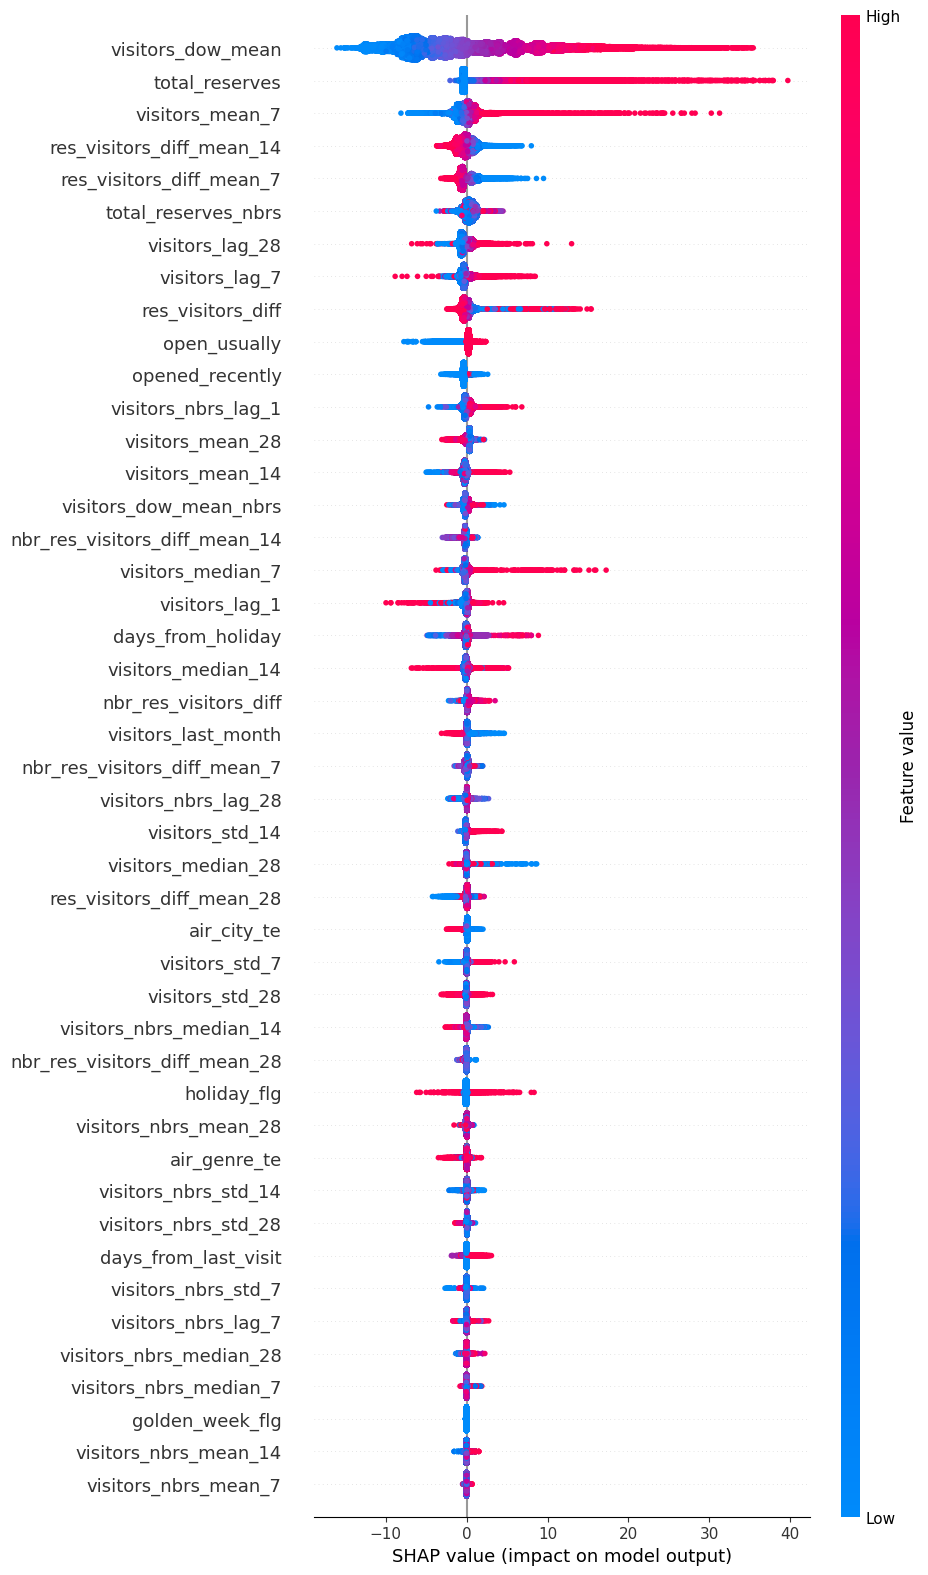

In [13]:
shap.plots.beeswarm(shap_values, max_display=15)

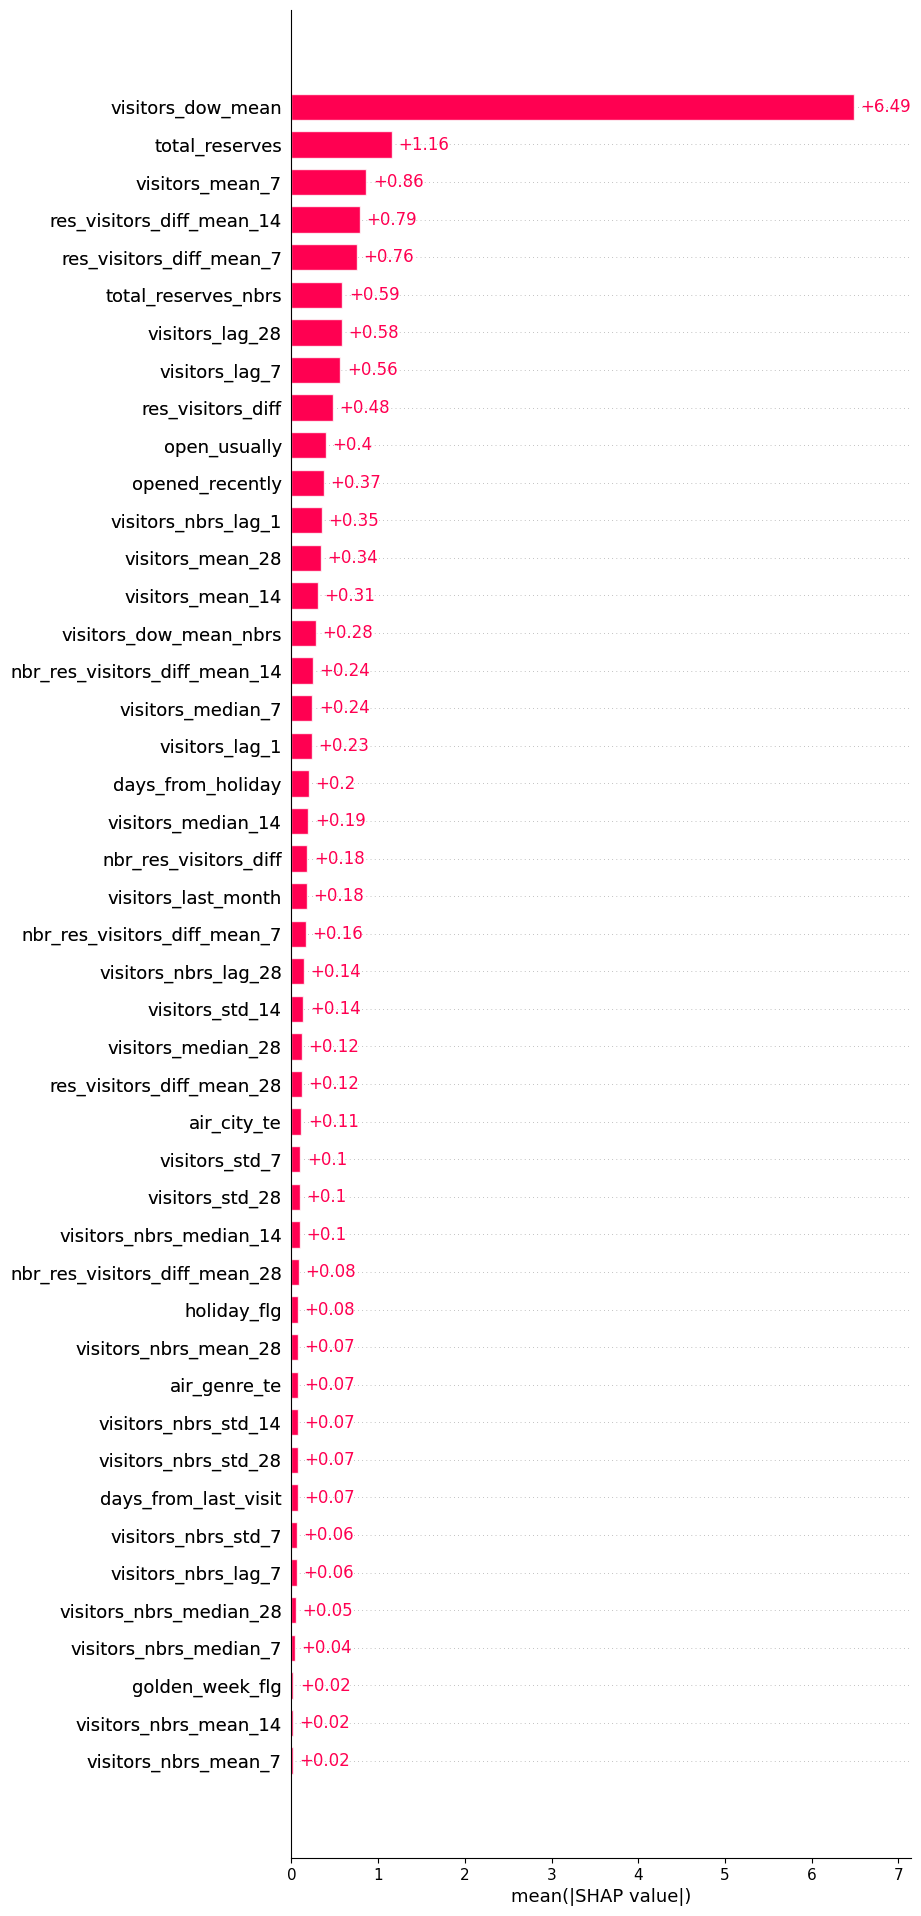

In [14]:
shap.plots.bar(shap_values, max_display=20)

### Visitors per day: actual vs predicted

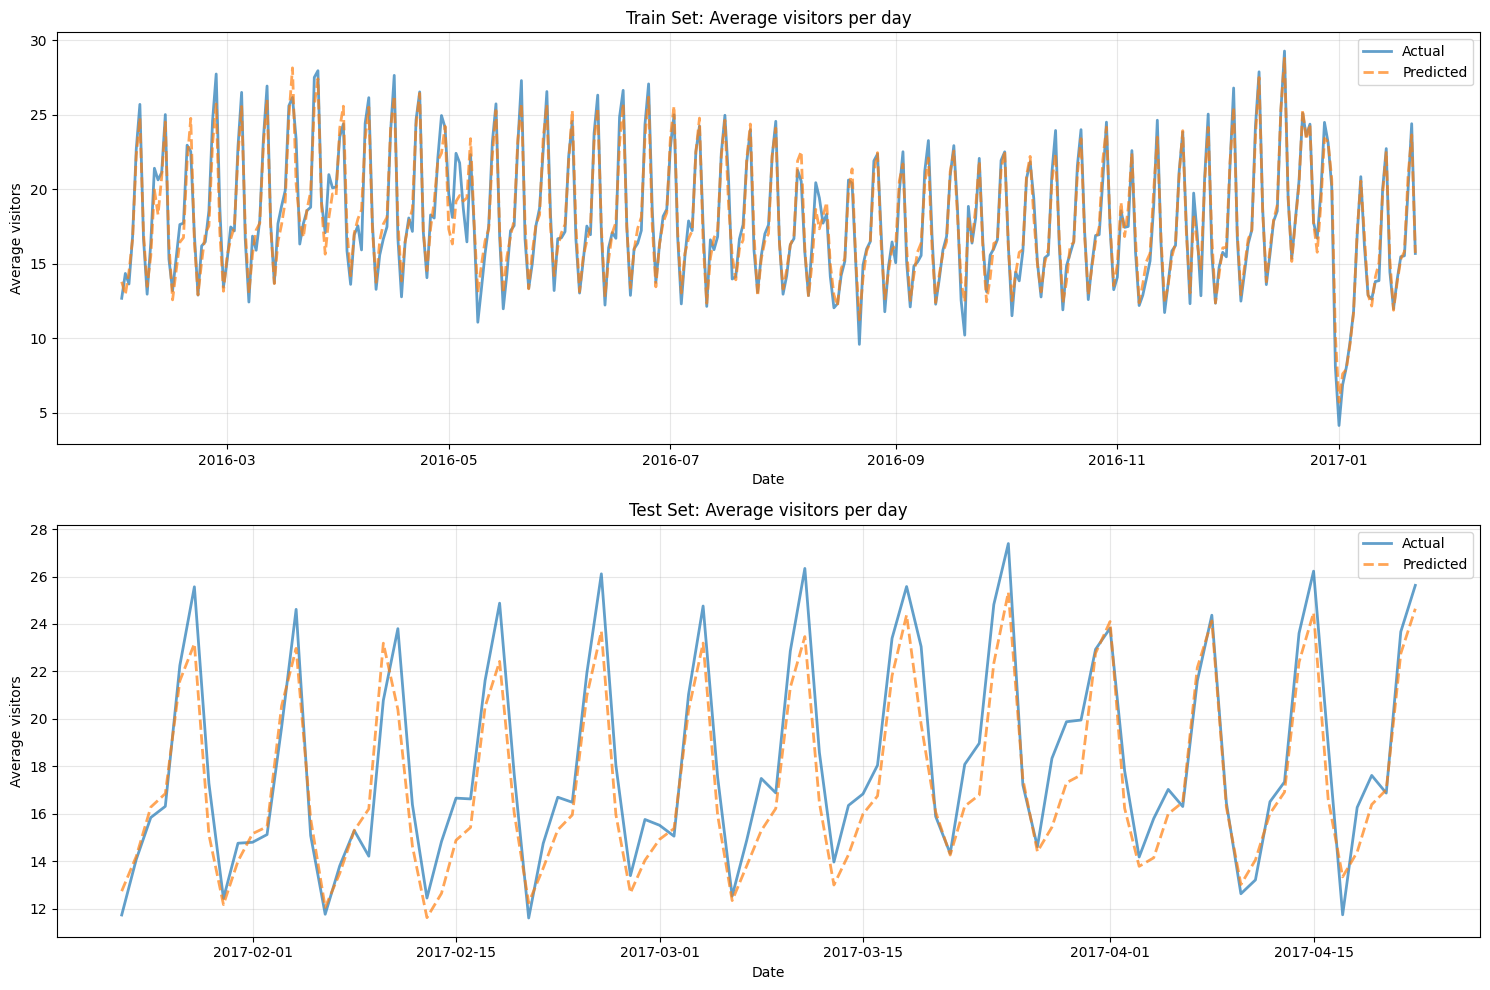

In [37]:
train_daily = merge_daily_pred(train_dates, y_train, y_train_pred)
test_daily = merge_daily_pred(test_dates, y_test, y_test_pred)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_daily_pred(train_daily, axes[0], train=True)
plot_daily_pred(test_daily, axes[1], train=False)

plt.tight_layout()
plt.show()

## Testing on future data

In [7]:
model = joblib.load(MODEL_PATH)

In [ ]:
test_features = read_csv("test_features.csv", DataDir.PROCESSED)
test_features = prepare_features(test_features)

In [40]:
test_labels, temp_features = recursive_predict(
    model_shap,
    test_features,
    X,
    y,
    drop_cols=FEATURES_TO_DROP,
)

Predicting recursively:   0%|          | 0/39 [00:00<?, ?it/s]D:\mentoring_program\recruit_restaurant_visitor_forecasting\modeling\predict.py:148: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[9.26234526e-01 3.82807950e-01 9.98857364e+00 5.28570935e+00
 2.25779739e+01 2.38185656e+01 2.71624936e+01 0.00000000e+00
 3.83116170e+01 1.40171232e+00 2.07589774e+01 4.68798157e+00
 2.82981940e+01 4.84240286e+01 2.29012503e+01 4.72138976e+00
 1.38087554e+01 1.11517258e+01 2.29868335e+01 5.00158806e+01
 5.84081103e+00 9.84631809e+00 1.33456524e+01 1.65282643e+01
 7.24418040e-01 2.75161468e+01 1.14634054e+01 2.02930693e+01
 6.69776841e-01 1.37436204e+01 2.14174408e+01 2.85576461e+00
 1.77694711e+01 8.78930376e+00 7.41035241e+00 1.85002043e-01
 2.18190418e+00 3.39086695e+01 2.24225056e+01 1.19510148e+01
 3.55709595e+01 3.90043696e+01 6.19958984e+00 4.57349379e-01
 1.53105566e+01 1.51875325e+01 8.86311968e-01 1.11203

In [41]:
labels_format = get_format(test_features, test_labels)
save_csv(labels_format, "test_labels.csv", DataDir.PROCESSED)

## Saving model

In [30]:
joblib.dump(model_shap, MODEL_PATH)
params_to_save = {
    "best_params": convert_to_serializable(study.best_params),
    "best_score": float(study.best_value),
    # "std": float(grid_search.cv_results_["std_test_score"][idx]),
    "features": FEATURES_TO_KEEP
}

PARAMS_PATH = MODELS_DIR / f"{MODEL_NAME}_params.json"
with open(PARAMS_PATH, 'w', encoding='utf-8') as f:
    json.dump(params_to_save, f, indent=2, ensure_ascii=False)